In [1]:
!pip3 install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
K_FACTORS = {
    "WORLD_CUP": 60,
    "CONTINENTAL_CUP": 53,
    "NATIONS_LEAGUE": 33,
    "QUALIFICATION": 30,
    "OLYMPICS": 23,
    "OTHER": 20,
    "FRIENDLY": 12
}

HOME_ADVANTAGE = 100
DEFAULT_ELO = 1500

In [10]:
df = pd.read_csv('../data/processed/matches_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df_asc = df.sort_values(by='date')

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,match_importance,winner
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,DRAW,FRIENDLY,NaN
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,HOME_WIN,FRIENDLY,NaN
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,HOME_WIN,FRIENDLY,NaN
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,DRAW,FRIENDLY,NaN
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,HOME_WIN,FRIENDLY,NaN


In [11]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating, expected, actual, k, mov):
    return rating + k * mov * (actual - expected)

In [18]:
elo_ratings = {}
history = []

In [19]:
for _, row in df.sort_values('date').iterrows():
    home_elo_pre = elo_ratings.get(row['home_team'], DEFAULT_ELO)
    away_elo_pre = elo_ratings.get(row['away_team'], DEFAULT_ELO)

    home_elo = home_elo_pre
    away_elo = away_elo_pre
    
    if not row['neutral']:
        home_elo += HOME_ADVANTAGE

    exp_home = expected_score(home_elo, away_elo)
    exp_away = expected_score(away_elo, home_elo)

    goal_diff = abs(row['home_score'] - row['away_score'])
    mov = np.log(goal_diff + 1)

    if row['result'] == 'HOME_WIN':
        actual_home = 1
    elif row['result'] == 'DRAW':
        actual_home = 0.5
    else:
        actual_home = 0

    actual_away = 1 - actual_home

    new_home_elo = update_elo(home_elo_pre, exp_home, actual_home, K_FACTORS[row['match_importance']], mov)
    new_away_elo = update_elo(away_elo_pre, exp_away, actual_away, K_FACTORS[row['match_importance']], mov)

    elo_ratings[row['home_team']] = new_home_elo
    elo_ratings[row['away_team']] = new_away_elo

    history.append({
    'date': row['date'],
    'home_team': row['home_team'],
    'away_team': row['away_team'],
    'home_elo_pre': home_elo_pre,
    'away_elo_pre': away_elo_pre,
    'home_elo_post': new_home_elo,
    'away_elo_post': new_away_elo,
    'result': row['result'],
    'neutral': row['neutral'],
    'match_importance': row['match_importance'],
    'elo_diff': home_elo_pre - away_elo_pre
    })

In [20]:
print(len(history))
history[0]

49215


{'date': Timestamp('1872-11-30 00:00:00'),
 'home_team': 'Scotland',
 'away_team': 'England',
 'home_elo_pre': 1500,
 'away_elo_pre': 1500,
 'home_elo_post': np.float64(1500.0),
 'away_elo_post': np.float64(1500.0),
 'result': 'DRAW',
 'neutral': False,
 'match_importance': 'FRIENDLY',
 'elo_diff': 0}

In [21]:
history[1]

{'date': Timestamp('1873-03-08 00:00:00'),
 'home_team': 'England',
 'away_team': 'Scotland',
 'home_elo_pre': np.float64(1500.0),
 'away_elo_pre': np.float64(1500.0),
 'home_elo_post': np.float64(1504.7451481720598),
 'away_elo_post': np.float64(1495.2548518279402),
 'result': 'HOME_WIN',
 'neutral': False,
 'match_importance': 'FRIENDLY',
 'elo_diff': np.float64(0.0)}

In [22]:
elo_history = pd.DataFrame(history)
elo_current = pd.DataFrame(elo_ratings.items(), columns=['team', 'elo'])

In [23]:
elo_history.to_csv('../data/processed/elo_history.csv', index=False)
elo_current.to_csv('../data/processed/elo_current.csv', index=False)

In [24]:
print(elo_history.shape)
print(elo_current.shape)

(49215, 11)
(333, 2)


In [25]:
elo_current.sort_values('elo', ascending=False).head(10)

,team,elo
39,Spain,2252.323868
7,Argentina,2194.000353
12,France,2184.250031
32,Brazil,2120.405939
1,England,2102.303388
85,Colombia,2050.129232
17,Netherlands,2049.768238
48,Portugal,2035.952390
20,Germany,2010.709760
6,Uruguay,1991.286437


In [26]:
elo_current.sort_values('elo', ascending=False).tail(5)

,team,elo
115,Macau,959.109177
226,Anguilla,947.506761
220,Bhutan,934.588305
219,Liechtenstein,931.789142
235,San Marino,854.285918


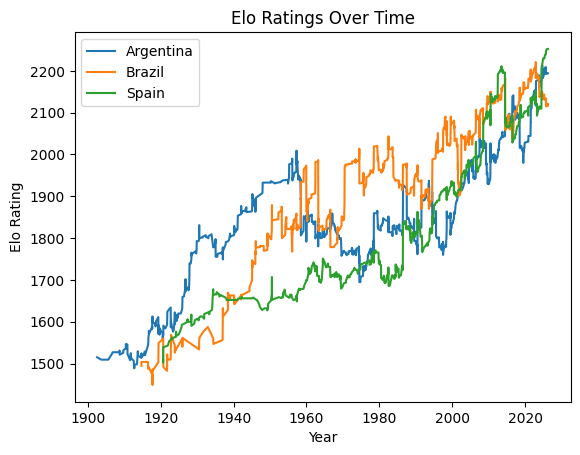

In [27]:
teams = ['Argentina', 'Brazil', 'Spain']
for team in teams:
    team_data = elo_history[(elo_history['home_team'] == team) | (elo_history['away_team'] == team)].copy()
    team_data['elo'] = team_data.apply(lambda x: x['home_elo_post'] if x['home_team'] == team else x['away_elo_post'], axis=1)
    plt.plot(team_data['date'], team_data['elo'], label=team)

plt.legend()
plt.title('Elo Ratings Over Time')
plt.xlabel('Year')
plt.ylabel('Elo Rating')
plt.show()